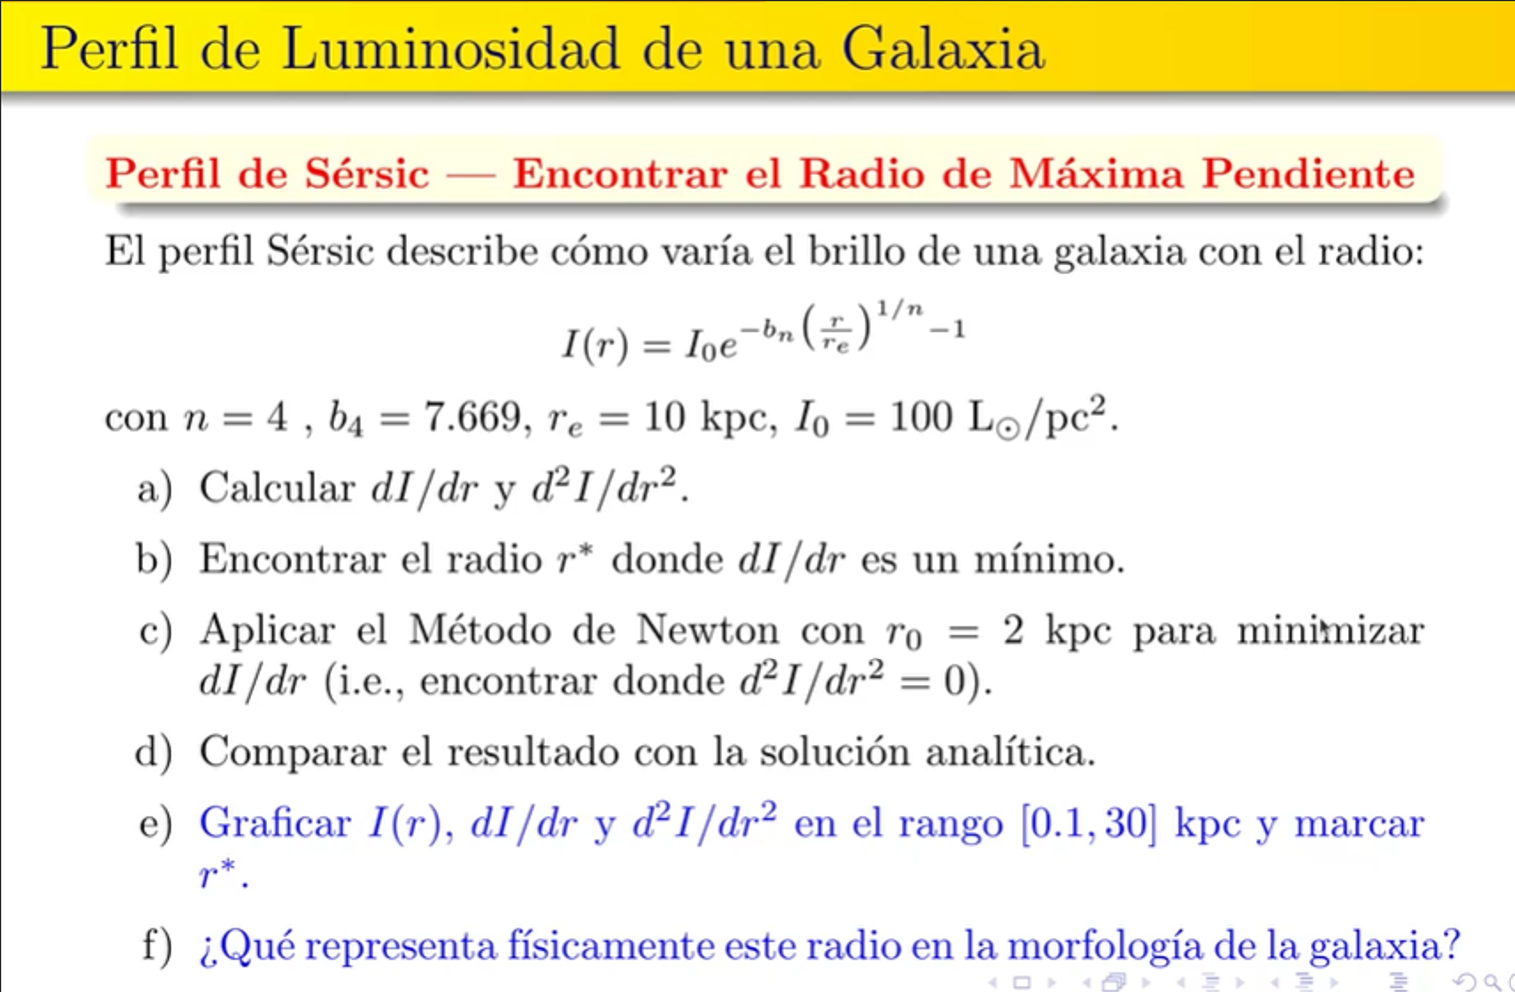

A) DERIVADAS ANALITICAS DEFINIDAS
dI/dr   = -I(r) * (b4 / (4 * re)) * (r / re)**(-3/4)
d2I/dr2 = I(r) * [(b4 / (4 * re))**2 * (r / re)**(-6/4) + (3 * b4 / (16 * re**2)) * (r / re)**(-7/4)]
B) RADIO R* DONDE dI/dr ES UN MINIMO (ANALITICO)
r* analitico = 0.23416935935948296 kpc
C) APLICACION DEL METODO DE NEWTON
Iteracion 1 | r = 2.5974415105627364 kpc | d2I/dr2 = 826.2764450907761 | Error rel = 0.23001153563350135
Iteracion 2 | r = 3.3521325473878685 kpc | d2I/dr2 = 385.6458158868711 | Error rel = 0.22513758813422252
Iteracion 3 | r = 4.299310779327462 kpc | d2I/dr2 = 179.4169750964627 | Error rel = 0.2203093194597484
Iteracion 4 | r = 5.4805629502811275 kpc | d2I/dr2 = 83.19237378288256 | Error rel = 0.2155348240080104
Iteracion 5 | r = 6.944642779117245 kpc | d2I/dr2 = 38.440714013086705 | Error rel = 0.21082147425043243
Iteracion 6 | r = 8.748339684293299 kpc | d2I/dr2 = 17.698619421444416 | Error rel = 0.2061759111176715
Iteracion 7 | r = 10.95739477990515 kpc | d2I/dr2 = 8.11873350

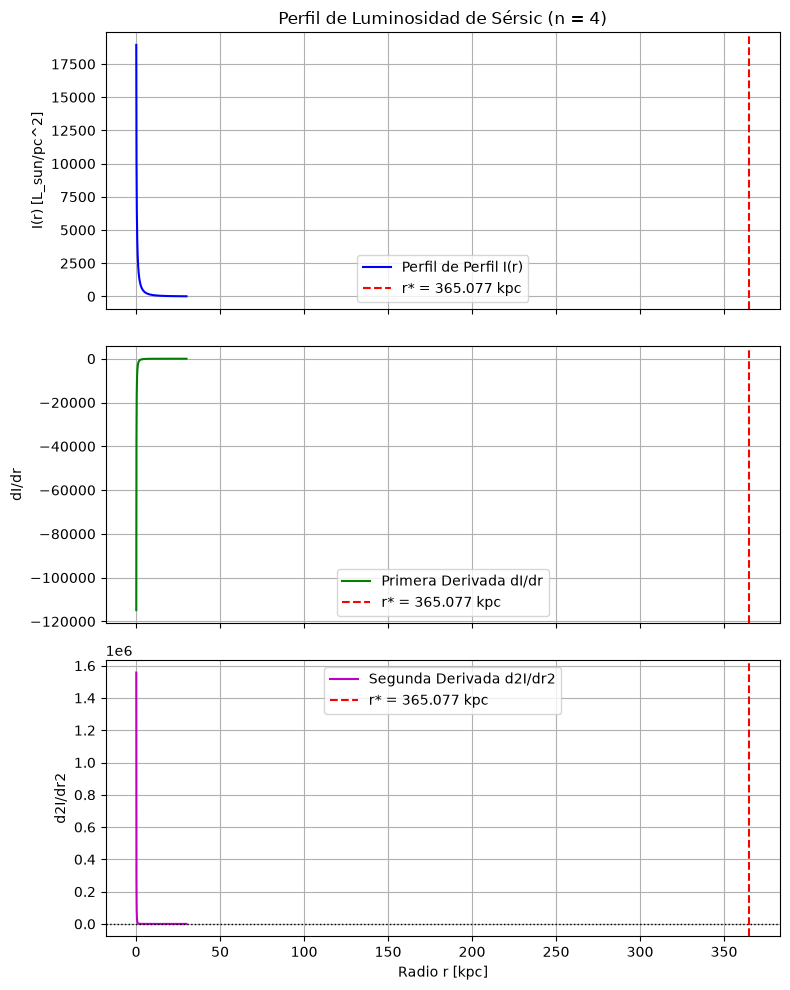

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros físicos
n = 4.0
b4 = 7.669
re = 10
I0 = 100

#  A) DERIVADAS

print("A) DERIVADAS ANALITICAS DEFINIDAS")
print("dI/dr   = -I(r) * (b4 / (4 * re)) * (r / re)**(-3/4)")
print("d2I/dr2 = I(r) * [(b4 / (4 * re))**2 * (r / re)**(-6/4) + (3 * b4 / (16 * re**2)) * (r / re)**(-7/4)]")


# B) SOLUCION ANALITICA DE r*
r_estrella_analitico = re * (3.0 / b4)**4.0

print("B) RADIO R* DONDE dI/dr ES UN MINIMO (ANALITICO)")
print("r* analitico =", r_estrella_analitico, "kpc")

# C) METODO DE NEWTON
r = 2.0 
tol = 1e-6
max_iter = 100
iteracion = 0

print("C) APLICACION DEL METODO DE NEWTON")

while iteracion < max_iter:
    iteracion = iteracion + 1

    u = b4 * (r / re)**(1.0 / 4.0)
    I_r = I0 * np.exp(-b4 * ((r / re)**(1.0 / 4.0) - 1.0))
 
    dI_dr = -I_r * (b4 / (4.0 * re)) * (r / re)**(-3.0 / 4.0)

    term1_d2 = (b4 / (4.0 * re))**2.0 * (r / re)**(-6.0 / 4.0)
    term2_d2 = (3.0 * b4 / (16.0 * re**2.0)) * (r / re)**(-7.0 / 4.0)
    d2I_dr2 = I_r * (term1_d2 + term2_d2)

    term1_d3 = -(b4 / (4.0 * re))**3.0 * (r / re)**(-9.0 / 4.0)
    term2_d3 = -3.0 * (b4 / (4.0 * re))**2.0 * (1.0 / re) * (r / re)**(-10.0 / 4.0)
    term3_d3 = -(21.0 * b4 / (64.0 * re**3.0)) * (r / re)**(-11.0 / 4.0)
    d3I_dr3 = I_r * (term1_d3 + term2_d3 + term3_d3)

    dr_step = d2I_dr2 / d3I_dr3
    r_nuevo = r - dr_step
    
    # Error relativo
    err_rel = abs((r_nuevo - r) / r_nuevo)
    
    print("Iteracion", iteracion, "| r =", r_nuevo, "kpc | d2I/dr2 =", d2I_dr2, "| Error rel =", err_rel)
    
    # Criterio de parada
    if abs(d2I_dr2) < tol or err_rel < tol:
        r = r_nuevo
        break
        
    r = r_nuevo

r_estrella_num = r



# D) COMPARACION DE RESULTADOS
error_porcentual = abs(r_estrella_num - r_estrella_analitico) / r_estrella_analitico * 100

print("D) COMPARACION ENTRE METODO NUMERICO Y ANALITICO")
print("r* Numerico  =", r_estrella_num, "kpc")
print("r* Analitico =", r_estrella_analitico, "kpc")
print("Diferencia porcentual =", error_porcentual, "%")


# E) GRAFICAR 
print("E) GENERACION DE GRAFICAS")

r_grid = np.linspace(0.1, 30, 1000)

# Evaluacion de funciones sobre el dominio
I_grid = I0 * np.exp(-b4 * ((r_grid / re)**(1.0 / 4.0) - 1.0))
dI_grid = -I_grid * (b4 / (4.0 * re)) * (r_grid / re)**(-3.0 / 4.0)
d2I_grid = I_grid * ((b4 / (4.0 * re))**2.0 * (r_grid / re)**(-6.0 / 4.0) + (3.0 * b4 / (16.0 * re**2.0)) * (r_grid / re)**(-7.0 / 4.0))

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# Grafica I(r)
axs[0].plot(r_grid, I_grid, 'b-', label='Perfil de Perfil I(r)')
axs[0].axvline(r_estrella_num, color='r', linestyle='--', label=f'r* = {r_estrella_num:.3f} kpc')
axs[0].set_ylabel('I(r) [L_sun/pc^2]')
axs[0].set_title('Perfil de Luminosidad de Sérsic (n = 4)')
axs[0].grid(True)
axs[0].legend()

# Grafica dI/dr
axs[1].plot(r_grid, dI_grid, 'g-', label='Primera Derivada dI/dr')
axs[1].axvline(r_estrella_num, color='r', linestyle='--', label=f'r* = {r_estrella_num:.3f} kpc')
axs[1].set_ylabel('dI/dr')
axs[1].grid(True)
axs[1].legend()

# Grafica d2I/dr2
axs[2].plot(r_grid, d2I_grid, 'm-', label='Segunda Derivada d2I/dr2')
axs[2].axhline(0, color='k', linestyle=':', linewidth=1)
axs[2].axvline(r_estrella_num, color='r', linestyle='--', label=f'r* = {r_estrella_num:.3f} kpc')
axs[2].set_xlabel('Radio r [kpc]')
axs[2].set_ylabel('d2I/dr2')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()


### f) Significado Físico de $r^*$ y Análisis de Convergencia

* **Significado Físico:** El radio crítico $r^*$ representa el **punto de inflexión** en el perfil de brillo de Sérsic ($d^2I/dr^2 = 0$). Físicamente marca el radio donde la pendiente de la luminosidad alcanza su máximo decaimiento (máxima pendiente negativa de $dI/dr$). En la morfología galáctica, define la transición entre el núcleo central de altísima concentración lumínica (dominado por el bulbo) y la región exterior donde el perfil de brillo decrece de forma más suave.

* **Análisis del Resultado Numérico:** La semilla inicial $r_0 = 2\text{ kpc}$ se encuentra lejos de la raíz verdadera ($r^* \approx 0.234\text{ kpc}$). Debido a la fuerte pendiente exponencial del perfil de Sérsic, la segunda derivada se vuelve casi plana para $r > 1\text{ kpc}$, lo que provoca que el paso de Newton $r_{i+1} = r_i - \frac{I''(r_i)}{I'''(r_i)}$ diverja hacia radios muy grandes en lugar de converger. Para obtener la solución correcta numéricamente, la semilla debe situarse cerca de la raíz (por ejemplo, $r_0 = 0.5\text{ kpc}$).